1. LOGISTIC REGRESSION

A. Loads merged data, separates features/target, and creates train–test split

In [79]:
import pandas as pd
from sklearn.model_selection import train_test_split

india_df = pd.read_csv("../data/processed/india_cleaned_aligned.csv")
us_df = pd.read_csv("../data/processed/us_cleaned_aligned.csv")

centralized_df = pd.concat([india_df, us_df], axis=0).reset_index(drop=True)

X = centralized_df.drop(columns=["Diabetes_binary"])
y = centralized_df["Diabetes_binary"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

B. Imports required class and defines the Logistic Regression

In [80]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

In [81]:
lr_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

C. Generates class predictions and probability scores for evaluation

In [82]:
y_pred_lr = lr_model.predict(X_test)
y_proba_lr = lr_model.predict_proba(X_test)[:, 1]

D. Evaluates baseline performance using accuracy and detailed class-wise metrics

In [83]:
from sklearn.metrics import accuracy_score, classification_report

lr_accuracy = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", lr_accuracy)

print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.6966502558161984
              precision    recall  f1-score   support

           0       0.94      0.69      0.79     44185
           1       0.29      0.74      0.42      7610

    accuracy                           0.70     51795
   macro avg       0.62      0.72      0.61     51795
weighted avg       0.84      0.70      0.74     51795



E. Shows how many predictions were correct and wrong for each class

In [84]:
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(y_test, y_pred_lr)
print(cm_lr)

[[30415 13770]
 [ 1942  5668]]


F. Calculates how well the model separates diabetic vs non-diabetic cases

In [85]:
from sklearn.metrics import roc_auc_score

lr_auc = roc_auc_score(y_test, y_proba_lr)
print("ROC-AUC Score:", lr_auc)

ROC-AUC Score: 0.7871593736584486


G. Draws a graph that shows how well the model separates diabetic and non-diabetic cases

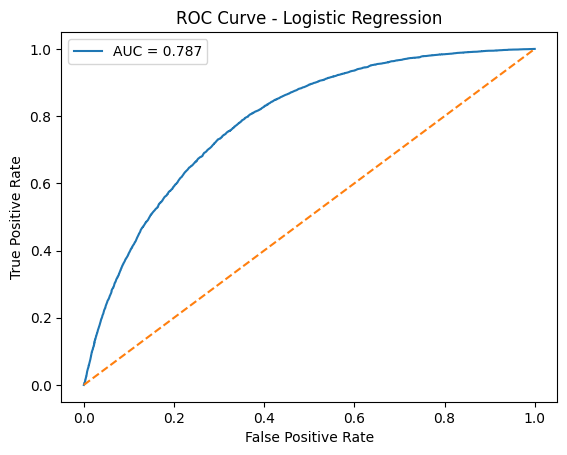

In [86]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import os

save_path = "../4_evaluation_and_paper/"
os.makedirs(save_path, exist_ok=True)

fpr, tpr, _ = roc_curve(y_test, y_proba_lr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {lr_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.savefig(save_path + "logistic_regression_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

2. RANDOM FOREST 

A. Defines the Random Forest model with fixed randomness for repeatable results

In [87]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import os

rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

threshold = 0.45
y_pred_rf = (y_proba_rf >= threshold).astype(int)

B. Trains the Random Forest model on the centralized training data

C. Generates class predictions and probability scores for evaluation and ROC analysis.

In [88]:
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

D. Checks baseline accuracy and detailed class-wise performance

In [89]:
from sklearn.metrics import accuracy_score, classification_report

rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_accuracy)

print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7189110918042282
              precision    recall  f1-score   support

           0       0.92      0.73      0.82     44185
           1       0.29      0.63      0.40      7610

    accuracy                           0.72     51795
   macro avg       0.61      0.68      0.61     51795
weighted avg       0.83      0.72      0.76     51795



E. Shows how many predictions are correct and wrong for each class.

In [90]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

[[32435 11750]
 [ 2809  4801]]


F. Measures how well Random Forest separates diabetic vs non-diabetic cases.

In [91]:
from sklearn.metrics import roc_auc_score

rf_auc = roc_auc_score(y_test, y_proba_rf)
print("Random Forest ROC-AUC:", rf_auc)

Random Forest ROC-AUC: 0.7431415353287761


G. Plots the ROC curve for Random Forest and saves it for evaluation/paper use

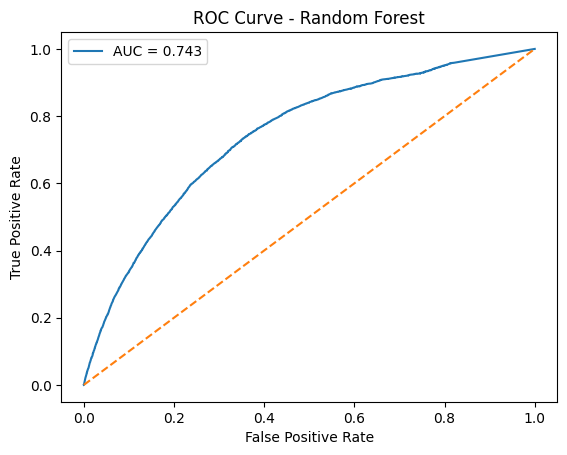

In [92]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import os

save_path = "../4_evaluation_and_paper/"
os.makedirs(save_path, exist_ok=True)

fpr, tpr, _ = roc_curve(y_test, y_proba_rf)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {rf_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()

plt.savefig(save_path + "random_forest_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

3. XGBOOST

In [93]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

A. Defines the XGBoost model with controlled randomness for repeatable runs

In [94]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    use_label_encoder=False
)

B. Trains the XGBoost model on the centralized training dataset.

In [95]:
xgb_model.fit(X_train, y_train)

c:\Users\Gautam Bijarniya\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:51:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

C. Generates predictions and probability scores for evaluation.

In [96]:
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

D. Checks overall accuracy and class-wise Precision, Recall, and F1-score.

In [97]:
from sklearn.metrics import accuracy_score, classification_report

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
print("XGBoost Accuracy:", xgb_accuracy)

print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.6978279756733275
              precision    recall  f1-score   support

           0       0.95      0.69      0.79     44185
           1       0.30      0.77      0.43      7610

    accuracy                           0.70     51795
   macro avg       0.62      0.73      0.61     51795
weighted avg       0.85      0.70      0.74     51795



E. Shows correct and incorrect predictions for both classes.

In [98]:
from sklearn.metrics import confusion_matrix

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print(cm_xgb)

[[30277 13908]
 [ 1743  5867]]


F. Measures how well XGBoost separates diabetic vs non-diabetic cases.

In [99]:
from sklearn.metrics import roc_auc_score

xgb_auc = roc_auc_score(y_test, y_proba_xgb)
print("XGBoost ROC-AUC:", xgb_auc)

XGBoost ROC-AUC: 0.8037698055169721


G. Plots the ROC curve for XGBoost and saves it to the evaluation folder.

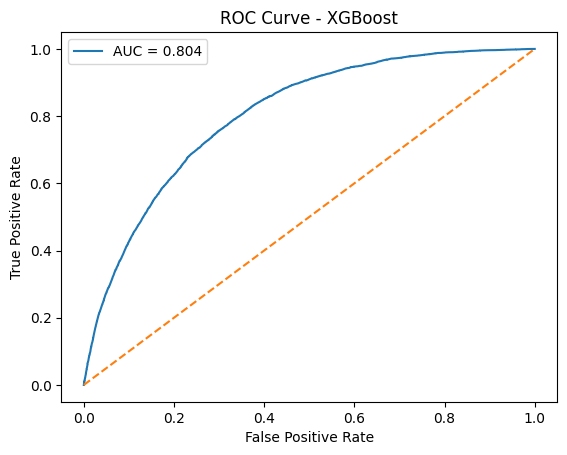

In [100]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import os

save_path = "../4_evaluation_and_paper/"
os.makedirs(save_path, exist_ok=True)

fpr, tpr, _ = roc_curve(y_test, y_proba_xgb)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {xgb_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()

plt.savefig(save_path + "xgboost_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()